# Appendix 1: Measure Zero and Sard's Theorem

**Source Span.** `Differential Topology.pdf` printed pages `202-207`. The appendix supplies the measure-zero machinery and proof scaffold for Sard's theorem: rectangular covers, volume bounds, Fubini slicing, smooth images of null sets, the manifold definition of measure zero, Mini-Sard, and the nested critical-set argument for Sard.

**Appendix Goal.** Understand why "almost every value is regular" is a precise analytic statement. Measure-zero sets are those that can be covered by boxes with arbitrarily small total volume. Smooth maps send sufficiently thin sets to thin sets after compact localization and Lipschitz control. Sard's proof decomposes the critical set into layers where Taylor expansion and dimension counting force the critical values to occupy zero volume.

This notebook is not a proof transcript. It is a visual and computational scaffold for the proof ideas. The cover diagrams track volume budgets. The Fubini panel tracks slice budgets. The smooth-image model shows how Lipschitz estimates keep image covers controlled. The fold/cusp lab shows critical sets and their images for maps whose Jacobian drops rank. The Taylor plot records the exponent condition that makes the high-order remainder shrink fast enough. The proof dependency graph then ties these pieces into the theorem.

The examples and prose are original and synthetic; no textbook diagrams, page crops, or long passages are reproduced.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Differential Topology course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = "appendix-1-measure-zero-and-sard-s-theorem"
UNIT_TITLE = "Measure Zero and Sard's Theorem"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
TRACKED_ARTIFACTS = []
np.set_printoptions(precision=5, suppress=True)
print(f"Book root: {BOOK_ROOT}")


Book root: D:\Geometry\Differential-Topology


## Visual Storyboard

1. **Null-cover budget.** A line segment and a graph curve are covered by thin rectangles. The learner inspects that total area can be made smaller than a chosen epsilon.
2. **Fubini slice tubes.** Vertical slices of a thin set are bounded by short intervals; integrating slice lengths gives a total-area budget.
3. **Smooth image control.** A compact null cover is mapped through a smooth map. Local Lipschitz control inflates boxes by a predictable factor, so image covers remain small when the source budget is small.
4. **Sard critical-value atlas.** Fold and cusp maps display critical sets, critical images, and symbolic Jacobian determinants.
5. **Taylor exponent and proof dependency.** A log-log plot shows when high-order Taylor remainder volume decays; a proof DAG records how the lemmas feed Sard.

## Library Routing

| Concept | Representation | Library | Why this route is used | Check |
| --- | --- | --- | --- | --- |
| Measure-zero covers | Rectangular cover diagrams | Matplotlib + NumPy | Box volumes are the definition and need visible budgets | total cover volume below epsilon |
| Fubini slicing | Slice lengths across vertical fibers | Matplotlib + CSV | The proof uses slice control to recover volume control | integrated slice bound equals area budget |
| Smooth image of null sets | Mapped boxes under a smooth function | Matplotlib + NumPy | Local Lipschitz behavior is geometric | image cover budget bounded by estimated scale factor |
| Sard local models | Critical sets/images for fold and cusp | Plotly + SymPy | Rank drop and critical values are inspectable | symbolic determinants match sampled critical sets |
| Taylor proof layer | Exponent-decay plot and proof DAG | Matplotlib + NetworkX | The theorem proof is a chain of reductions | decay occurs only past the threshold; DAG reaches Sard |


## Null Covers And Fubini Slices

A subset of Euclidean space has measure zero if, for every positive budget, it can be covered by boxes whose total volume is below that budget. The definition is intentionally operational: the set may be infinite, but the cover has a sum that can be made arbitrarily small. A line segment in the plane is the simplest example. Cover it by a thin rectangle of height `2δ`; its area is `2δ` times the length. Letting `δ` shrink drives the area to zero.

Fubini's principle gives a second way to think about thinness. If most vertical slices have zero or very small one-dimensional length and the total slice-length integral is small, then the planar set is small. Sard's proof uses this kind of slicing after local coordinate reductions. The figure below shows both pictures: direct thin boxes and a family of vertical slice intervals. The saved JSON records the area budget and the integrated slice bound.


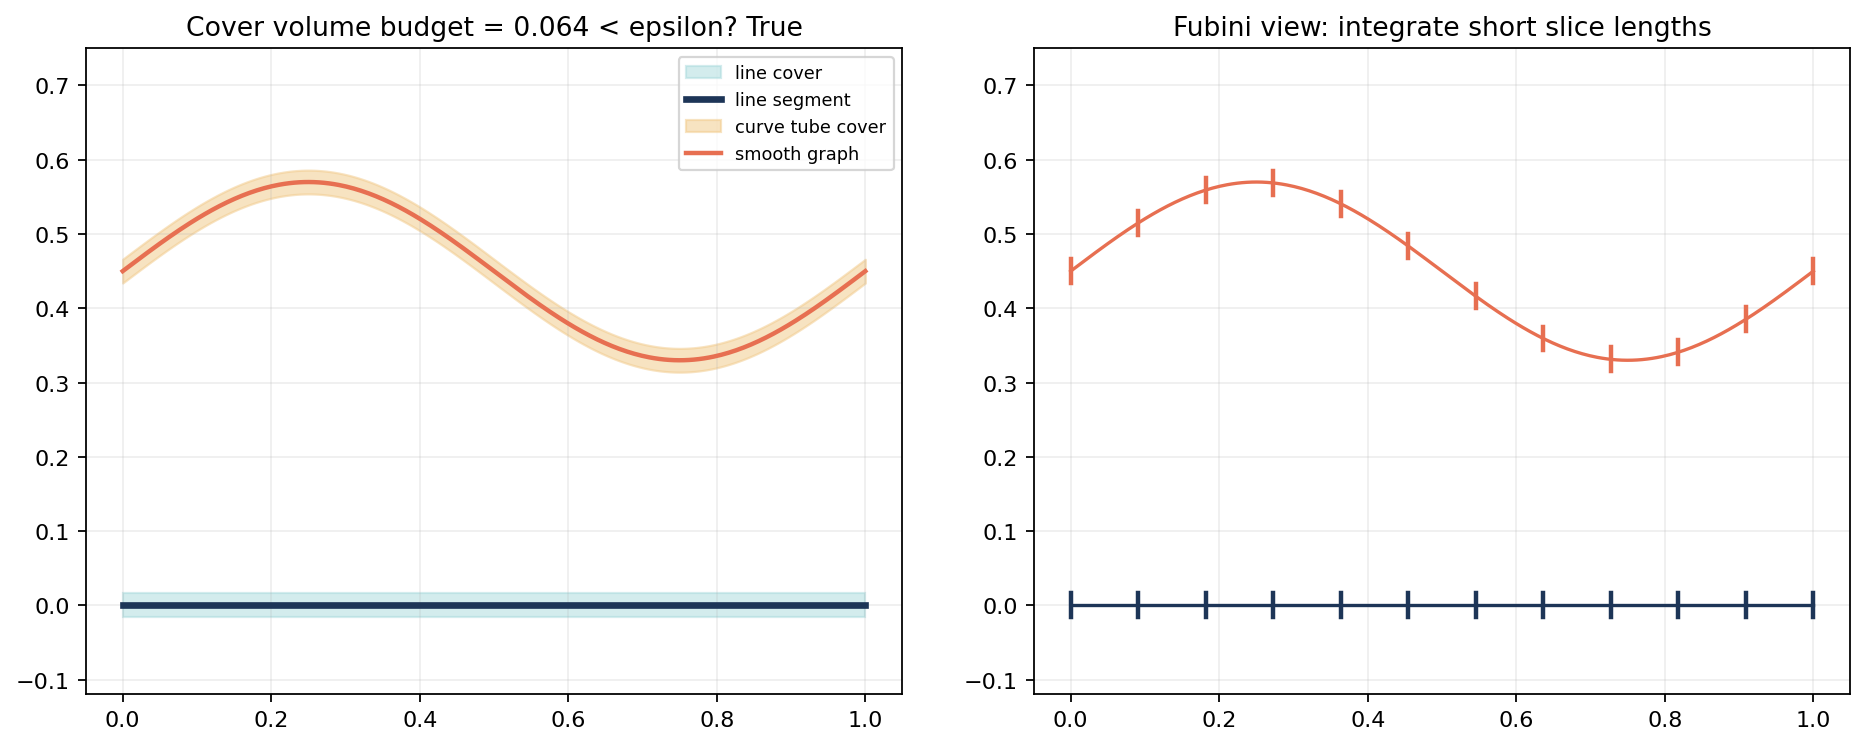

{'epsilon': 0.08,
 'delta': 0.016,
 'line_cover_area': 0.032,
 'curve_cover_area': 0.032,
 'total_cover_budget': 0.064,
 'below_epsilon': True,
 'slice_integral_bound': 0.064}

In [2]:
epsilon = 0.08
delta = epsilon / 5
x = np.linspace(0, 1, 300)
curve_y = 0.45 + 0.12*np.sin(2*np.pi*x)
cover_area_line = 1.0 * (2*delta)
cover_area_curve = 1.0 * (2*delta)
total_cover_budget = cover_area_line + cover_area_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].add_patch(plt.Rectangle((0, -delta), 1, 2*delta, color="#a8dadc", alpha=0.5, label="line cover"))
axes[0].plot([0, 1], [0, 0], color="#1d3557", lw=3, label="line segment")
axes[0].fill_between(x, curve_y-delta, curve_y+delta, color="#f2cc8f", alpha=0.55, label="curve tube cover")
axes[0].plot(x, curve_y, color="#e76f51", lw=2, label="smooth graph")
axes[0].set_title(f"Cover volume budget = {total_cover_budget:.3f} < epsilon? {total_cover_budget < epsilon}")
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.12, 0.75)
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(alpha=0.2)

slice_x = np.linspace(0, 1, 12)
for sx in slice_x:
    sy = 0.45 + 0.12*np.sin(2*np.pi*sx)
    axes[1].plot([sx, sx], [sy-delta, sy+delta], color="#e76f51", lw=2)
    axes[1].plot([sx, sx], [-delta, delta], color="#1d3557", lw=2)
axes[1].plot(x, curve_y, color="#e76f51", lw=1.5)
axes[1].plot([0, 1], [0, 0], color="#1d3557", lw=1.5)
axes[1].set_title("Fubini view: integrate short slice lengths")
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.12, 0.75)
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=0.2)
fig.tight_layout()
cover_path = save_matplotlib(fig, FIGURES / "null-cover-and-fubini-slice-budget.png")
plt.close(fig)
cover_check = {
    "epsilon": epsilon,
    "delta": delta,
    "line_cover_area": cover_area_line,
    "curve_cover_area": cover_area_curve,
    "total_cover_budget": total_cover_budget,
    "below_epsilon": total_cover_budget < epsilon,
    "slice_integral_bound": total_cover_budget,
}
cover_json = save_json(cover_check, CHECKS / "cover-volume-and-fubini-slice-budget.json")
TRACKED_ARTIFACTS.extend([cover_path, cover_json])
display_artifact(cover_path, width=840)
cover_check


## Smooth Images Of Thin Sets

A smooth map on a compact coordinate patch is Lipschitz after possibly increasing the constant. That means a small box in the domain maps into a controlled box in the target. This is the analytic bridge from null covers in the source to null covers in the image. The exact constants are not the point of the diagram; the point is that compactness makes one constant work on the patch, so shrinking the source cover shrinks the image cover.

The synthetic map below sends `(x,y)` to `(x, y + 0.25 sin(2πx))`. Thin rectangles around the x-axis are mapped to thin curved rectangles around a graph. The code estimates a conservative Lipschitz factor from sampled Jacobian norms and compares the observed image bounding-box budget to a Lipschitz-scaled source budget. This is a computational version of the appendix's smooth-image control lemma.


C:\Users\rahul\AppData\Local\Temp\ipykernel_32056\3720969908.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axes[0].add_patch(plt.Polygon(box, closed=True, fill=True, color="#a8dadc", alpha=0.45, edgecolor="#1d3557"))
C:\Users\rahul\AppData\Local\Temp\ipykernel_32056\3720969908.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axes[1].add_patch(plt.Rectangle((xmin, ymin), width, height, color="#f2cc8f", alpha=0.48, edgecolor="#e76f51"))


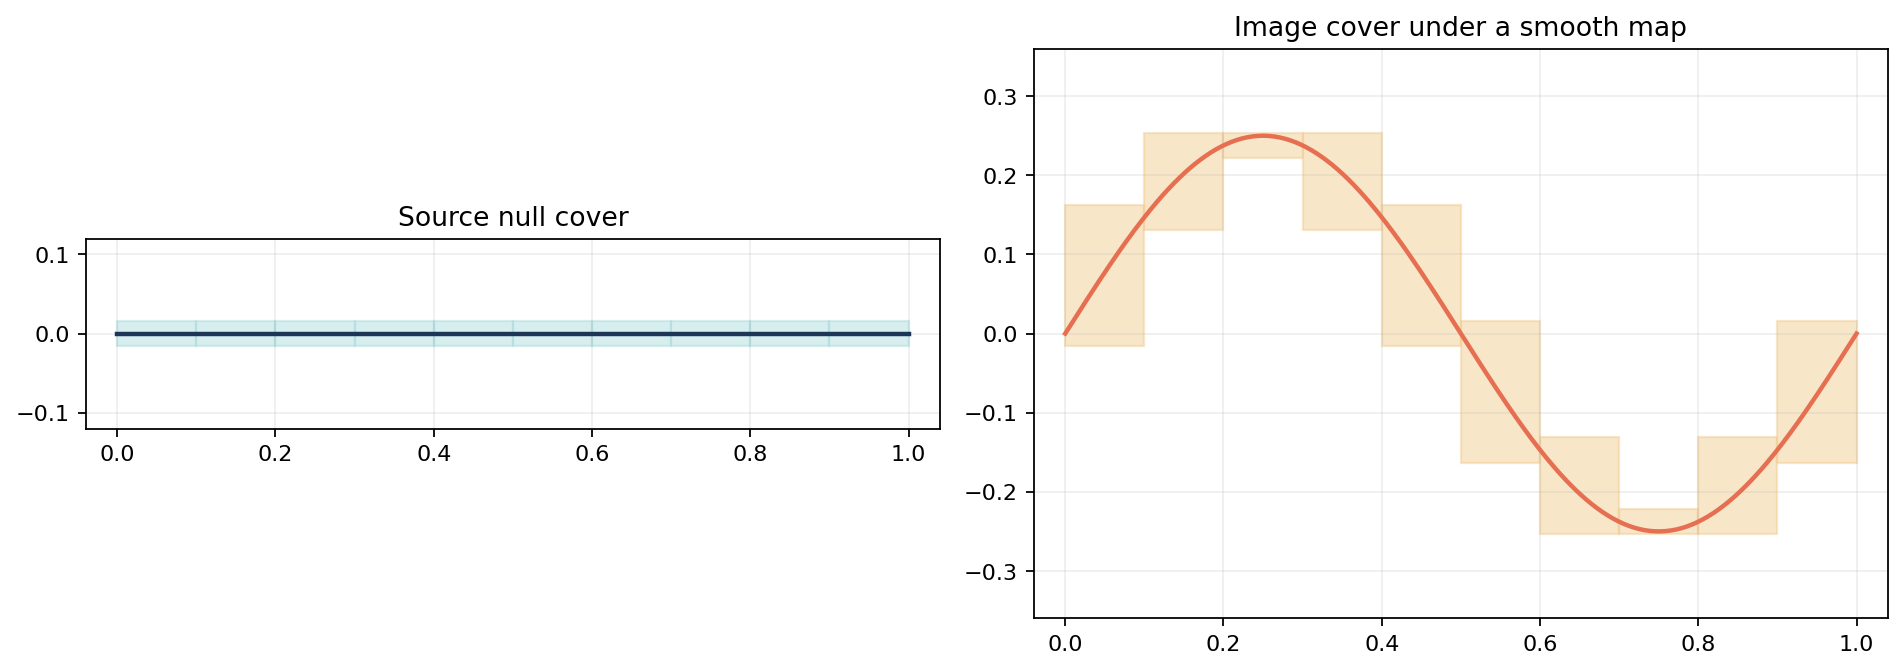

{'source_area': 0.031999999999999994,
 'observed_image_box_area_sum': np.float64(0.12710565162951534),
 'estimated_lipschitz_constant': 2.0569524387109657,
 'lipschitz_scaled_source_bound': 0.1353937067238076,
 'observed_below_scaled_bound': True}

In [3]:
def F(points):
    pts = np.asarray(points)
    return np.column_stack([pts[:, 0], pts[:, 1] + 0.25*np.sin(2*np.pi*pts[:, 0])])

segments = 10
source_boxes = []
image_boxes = []
source_area = 0.0
image_area = 0.0
for k in range(segments):
    x0, x1 = k/segments, (k+1)/segments
    corners = np.array([[x0, -delta], [x1, -delta], [x1, delta], [x0, delta]])
    mapped = F(corners)
    source_boxes.append(corners)
    xmin, ymin = mapped.min(axis=0)
    xmax, ymax = mapped.max(axis=0)
    image_boxes.append((xmin, ymin, xmax-xmin, ymax-ymin))
    source_area += (x1-x0) * (2*delta)
    image_area += (xmax-xmin) * (ymax-ymin)

sample_x = np.linspace(0, 1, 200)
# Jacobian [[1,0],[0.5*pi*cos(2pi x),1]]; use spectral norms.
norms = []
for sx in sample_x:
    J = np.array([[1.0, 0.0], [0.5*np.pi*np.cos(2*np.pi*sx), 1.0]])
    norms.append(np.linalg.norm(J, 2))
L_est = float(max(norms))
scaled_bound = (L_est**2) * source_area

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for box in source_boxes:
    axes[0].add_patch(plt.Polygon(box, closed=True, fill=True, color="#a8dadc", alpha=0.45, edgecolor="#1d3557"))
axes[0].plot(np.linspace(0, 1, 200), np.zeros(200), color="#1d3557", lw=2)
axes[0].set_title("Source null cover")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(-0.04, 1.04)
axes[0].set_ylim(-0.12, 0.12)
axes[0].grid(alpha=0.2)
for xmin, ymin, width, height in image_boxes:
    axes[1].add_patch(plt.Rectangle((xmin, ymin), width, height, color="#f2cc8f", alpha=0.48, edgecolor="#e76f51"))
xx = np.linspace(0, 1, 300)
axes[1].plot(xx, 0.25*np.sin(2*np.pi*xx), color="#e76f51", lw=2)
axes[1].set_title("Image cover under a smooth map")
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlim(-0.04, 1.04)
axes[1].set_ylim(-0.36, 0.36)
axes[1].grid(alpha=0.2)
fig.tight_layout()
image_path = save_matplotlib(fig, FIGURES / "smooth-image-nullset-lipschitz-control.png")
plt.close(fig)
image_check = {
    "source_area": source_area,
    "observed_image_box_area_sum": image_area,
    "estimated_lipschitz_constant": L_est,
    "lipschitz_scaled_source_bound": scaled_bound,
    "observed_below_scaled_bound": bool(image_area <= scaled_bound),
}
image_json = save_json(image_check, CHECKS / "smooth-image-nullset-lipschitz-control.json")
TRACKED_ARTIFACTS.extend([image_path, image_json])
display_artifact(image_path, width=840)
image_check


## Critical Values In Fold And Cusp Models

Sard's theorem concerns the image of the critical set, where the derivative drops rank. In a map from the plane to the plane, this is detected by the determinant of the Jacobian. For the fold map `(x,y) -> (x,y^2)`, the critical set is the x-axis and the critical image is also a line. For a cusp-flavored map `(x,y) -> (x, y^3 + xy)`, the critical set is a parabola-like curve and its image has a cusp shape. In both examples the critical image is visually thin in the target plane.

These examples are local models, not a proof of Sard. They help separate three objects that are easy to confuse: the domain, the critical set inside the domain, and the critical values inside the target. The symbolic determinant check keeps the drawing honest.


In [4]:
x_sym, y_sym = sp.symbols("x y")
fold = sp.Matrix([x_sym, y_sym**2])
cusp = sp.Matrix([x_sym, y_sym**3 + x_sym*y_sym])
def jac_det(expr):
    return sp.simplify(sp.Matrix(expr).jacobian([x_sym, y_sym]).det())
fold_det = jac_det(fold)
cusp_det = jac_det(cusp)

x_vals = np.linspace(-1.2, 1.2, 350)
y_fold = np.zeros_like(x_vals)
fold_image = np.column_stack([x_vals, y_fold])
y_c = np.linspace(-0.9, 0.9, 350)
x_c = -3*y_c**2
cusp_crit = np.column_stack([x_c, y_c])
cusp_image = np.column_stack([x_c, y_c**3 + x_c*y_c])
fig = go.Figure()
fig.add_trace(go.Scatter(x=x_vals, y=y_fold, mode="lines", line=dict(color="#1d3557", width=3), name="fold critical set/image"))
fig.add_trace(go.Scatter(x=cusp_crit[:,0], y=cusp_crit[:,1], mode="lines", line=dict(color="#2a9d8f", width=3), name="cusp critical set in domain"))
fig.add_trace(go.Scatter(x=cusp_image[:,0], y=cusp_image[:,1], mode="lines", line=dict(color="#e76f51", width=3), name="cusp critical image"))
fig.update_layout(title="Sard local atlas: critical sets and critical images", xaxis_title="first coordinate", yaxis_title="second coordinate", width=780, height=620, yaxis_scaleanchor="x")
sard_html = save_plotly_html(fig, HTML / "sard-critical-value-atlas.html")
sard_check = {
    "fold_jacobian_determinant": str(fold_det),
    "fold_critical_equation": "y=0",
    "cusp_jacobian_determinant": str(cusp_det),
    "cusp_critical_equation": "x=-3*y**2",
    "sampled_cusp_image_points": int(len(cusp_image)),
}
sard_json = save_json(sard_check, CHECKS / "sard-critical-value-atlas.json")
TRACKED_ARTIFACTS.extend([sard_html, sard_json])
display_artifact(sard_html, width=820, height=620)
sard_check


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'fold_jacobian_determinant': '2*y',
 'fold_critical_equation': 'y=0',
 'cusp_jacobian_determinant': 'x + 3*y**2',
 'cusp_critical_equation': 'x=-3*y**2',
 'sampled_cusp_image_points': 350}

## Taylor Decay And The Proof Dependency Graph

The last part of Sard's proof splits the critical set into layers according to how many derivatives vanish. Once enough derivatives vanish, Taylor's theorem says the image of a small cube is much smaller than a generic image. The exponent controls whether the total volume of the image cover decays to zero as the cube size shrinks. The threshold is schematic here: decay occurs when the exponent is positive, equivalently when the order of vanishing is large enough relative to source and target dimensions.

The plot shows this as a log-log budget. Negative values of `n - p(k+1)` fall toward zero as the mesh size shrinks; nonnegative values do not give the needed decay. The dependency graph then places that estimate alongside the earlier measure-zero tools: covers, Fubini, smooth-image control, coordinate reduction, critical-set layers, and finally Sard.


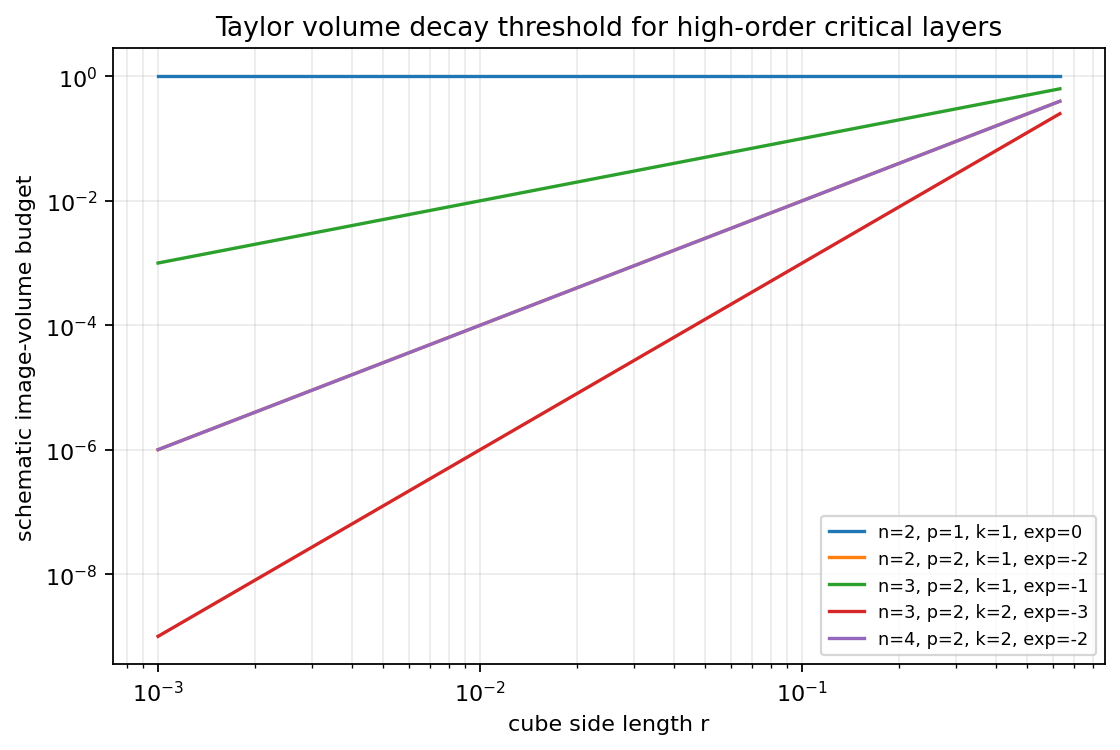

[{'source_dim_n': 2,
  'target_dim_p': 1,
  'vanishing_order_k': 1,
  'exponent_n_minus_p_k_plus_1': 0,
  'decays_to_zero': False},
 {'source_dim_n': 2,
  'target_dim_p': 2,
  'vanishing_order_k': 1,
  'exponent_n_minus_p_k_plus_1': -2,
  'decays_to_zero': True},
 {'source_dim_n': 3,
  'target_dim_p': 2,
  'vanishing_order_k': 1,
  'exponent_n_minus_p_k_plus_1': -1,
  'decays_to_zero': True},
 {'source_dim_n': 3,
  'target_dim_p': 2,
  'vanishing_order_k': 2,
  'exponent_n_minus_p_k_plus_1': -3,
  'decays_to_zero': True},
 {'source_dim_n': 4,
  'target_dim_p': 2,
  'vanishing_order_k': 2,
  'exponent_n_minus_p_k_plus_1': -2,
  'decays_to_zero': True}]

In [5]:
r = np.logspace(-3, -0.2, 120)
threshold_rows = []
curves = []
for n, p, k in [(2, 1, 1), (2, 2, 1), (3, 2, 1), (3, 2, 2), (4, 2, 2)]:
    exponent = n - p*(k+1)
    budget = r**(-exponent) if exponent < 0 else r**(max(exponent, 0))
    decays = exponent < 0
    threshold_rows.append({"source_dim_n": n, "target_dim_p": p, "vanishing_order_k": k, "exponent_n_minus_p_k_plus_1": exponent, "decays_to_zero": decays})
    curves.append((f"n={n}, p={p}, k={k}, exp={exponent}", budget))

fig, ax = plt.subplots(figsize=(8, 5))
for label, budget in curves:
    ax.loglog(r, budget, label=label)
ax.set_xlabel("cube side length r")
ax.set_ylabel("schematic image-volume budget")
ax.set_title("Taylor volume decay threshold for high-order critical layers")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=8)
taylor_path = save_matplotlib(fig, FIGURES / "taylor-cube-volume-decay-threshold.png")
plt.close(fig)
taylor_csv = save_csv(threshold_rows, TABLES / "taylor-cube-volume-decay-threshold.csv")
taylor_json = save_json({"rows": threshold_rows}, CHECKS / "taylor-cube-volume-decay-threshold.json")
TRACKED_ARTIFACTS.extend([taylor_path, taylor_csv, taylor_json])
display_artifact(taylor_path, width=760)
threshold_rows


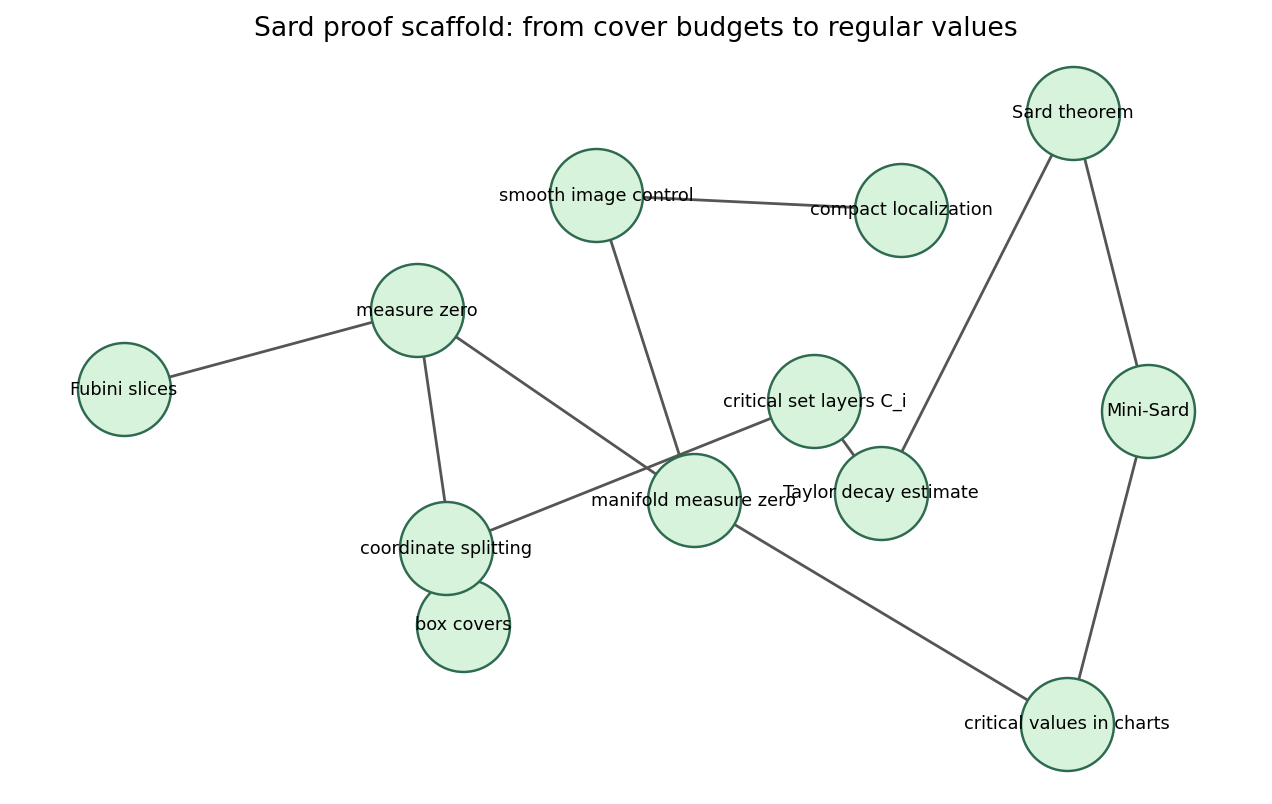

{'nodes': 12, 'edges': 11, 'acyclic': True}

In [6]:
G = nx.DiGraph()
edges = [
    ("box covers", "measure zero"),
    ("Fubini slices", "measure zero"),
    ("measure zero", "manifold measure zero"),
    ("compact localization", "smooth image control"),
    ("smooth image control", "manifold measure zero"),
    ("manifold measure zero", "critical values in charts"),
    ("critical values in charts", "Mini-Sard"),
    ("Mini-Sard", "Sard theorem"),
    ("critical set layers C_i", "Taylor decay estimate"),
    ("Taylor decay estimate", "Sard theorem"),
    ("coordinate splitting", "critical set layers C_i"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=52, k=0.9)
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color="#555555", width=1.25)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#d8f3dc", edgecolors="#2d6a4f", linewidths=1.1, node_size=1750)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Sard proof scaffold: from cover budgets to regular values")
ax.axis("off")
dep_path = save_matplotlib(fig, FIGURES / "sard-proof-dependency-graph.png")
plt.close(fig)
dep_json = save_json({"nodes": list(G.nodes), "edges": edges, "acyclic": nx.is_directed_acyclic_graph(G), "sard_reachable_from_box_covers": nx.has_path(G, "box covers", "Sard theorem")}, CHECKS / "sard-proof-dependency-graph.json")
TRACKED_ARTIFACTS.extend([dep_path, dep_json])
display_artifact(dep_path, width=780)
{"nodes": G.number_of_nodes(), "edges": G.number_of_edges(), "acyclic": nx.is_directed_acyclic_graph(G)}


## Applied Lab: Validating The Analytic Scaffold

A useful way to read this appendix is as a sequence of budgets. A null set is controlled by a cover budget. A Fubini argument controls the total budget by integrating slice budgets. A smooth map on a compact patch inflates budgets by a bounded amount. Sard's proof then focuses that logic on the image of the critical set. Low-order critical layers are handled by coordinate splitting and induction; high-order layers are handled by Taylor decay.

The diagnostics above are intentionally finite. They do not prove that an arbitrary critical image has measure zero. They do show what each proof ingredient is responsible for: the cover budget must be arbitrarily small, the image budget must remain controlled, the critical set must be separated from its critical values, and the Taylor exponent must be positive in the relevant layer. That is enough scaffolding to make the theorem's proof strategy memorable and checkable.


In [7]:
assert cover_check["below_epsilon"]
assert image_check["observed_below_scaled_bound"]
assert sp.simplify(fold_det - 2*y_sym) == 0
assert sp.simplify(cusp_det - (x_sym + 3*y_sym**2)) == 0
assert any(row["decays_to_zero"] for row in threshold_rows)
assert any(not row["decays_to_zero"] for row in threshold_rows)
assert nx.is_directed_acyclic_graph(G)
assert nx.has_path(G, "box covers", "Sard theorem")
assert_artifacts(TRACKED_ARTIFACTS, min_bytes=80)
final_sanity = {
    "unit": UNIT_KEY,
    "tracked_artifacts": len(TRACKED_ARTIFACTS),
    "core_checks": ["cover budget", "Fubini slice budget", "smooth image Lipschitz control", "critical determinant equations", "Taylor decay threshold", "proof DAG"],
}
final_sanity


{'unit': 'appendix-1-measure-zero-and-sard-s-theorem',
 'tracked_artifacts': 11,
 'core_checks': ['cover budget',
  'Fubini slice budget',
  'smooth image Lipschitz control',
  'critical determinant equations',
  'Taylor decay threshold',
  'proof DAG']}

## Takeaways

Measure zero is a cover-budget concept, not a vague synonym for small. Fubini slicing and compact Lipschitz control are the main analytic devices that let the budget survive coordinate changes and smooth maps. Sard's theorem applies those devices to the critical set of a smooth map. The theorem does not say critical points are rare; it says critical values form a measure-zero subset of the target. That distinction is essential for the regular-value arguments used throughout differential topology.

When a chapter invokes Sard, read it as permission to choose a target value or perturbation outside a thin exceptional set. The computational habit is: identify the derivative rank condition, isolate the critical set, track the critical image, and keep the measure-zero budget attached to the argument.
